# 05. So sánh tổng hợp

Mỗi thuật toán được lấy ở cấu hình tốt nhất xác định được từ notebook 03 và 04,
rồi vẽ chung trên hai hình: theo số vòng lặp và theo thời gian chạy. Đây là cặp
hình chính của bài trình bày.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from src.plotting import set_style

set_style()


In [2]:
from src.data import load_problem
from src.plotting import plot_comparison, summary_table
from src.runner import best_result, load_results

problem, config = load_problem()

groups = {}
for name in ("gd_fixed", "gd_backtracking", "sgd_batch", "sgd_schedule", "agd", "newton", "lbfgs"):
    try:
        groups[name], _ = load_results(name)
    except FileNotFoundError:
        print(f"chưa có kết quả cho nhóm {name}, chạy notebook tương ứng trước")

print("đã nạp:", list(groups))

đã nạp: ['gd_fixed', 'gd_backtracking', 'sgd_batch', 'sgd_schedule', 'agd', 'newton', 'lbfgs']


## Chọn cấu hình tốt nhất của từng thuật toán

Tiêu chí: thời gian ngắn nhất để đạt `f - f* < 1e-6`. Các cấu hình không bao giờ
đạt ngưỡng được xếp sau, theo giá trị hàm mục tiêu cuối cùng.

In [3]:
THRESHOLD = 1e-6

best = []
for name, runs in groups.items():
    chosen = best_result(runs, problem.f_star, threshold=THRESHOLD)
    chosen.params["label"] = f"{chosen.params.get('label', chosen.method)}"
    best.append(chosen)
    print(f"{name:<18s} -> {chosen.params['label']}")

gd_fixed           -> GD ($t = 2/L$)
gd_backtracking    -> GD bt ($\alpha = 0.5$, $\beta = 0.5$)
sgd_batch          -> SGD ($B = 256$, $\eta = 1/L_B = 0.0675$)
sgd_schedule       -> SGD ($B = 64$, $\eta_k = \eta_0 \cdot 2^{-\lfloor k/5 \rfloor}$)
agd                -> AGD ($\beta_k = (k-1)/(k+2)$) + restart
newton             -> Newton ($t = 1$, cached factor)
lbfgs              -> L-BFGS ($m = 20$)


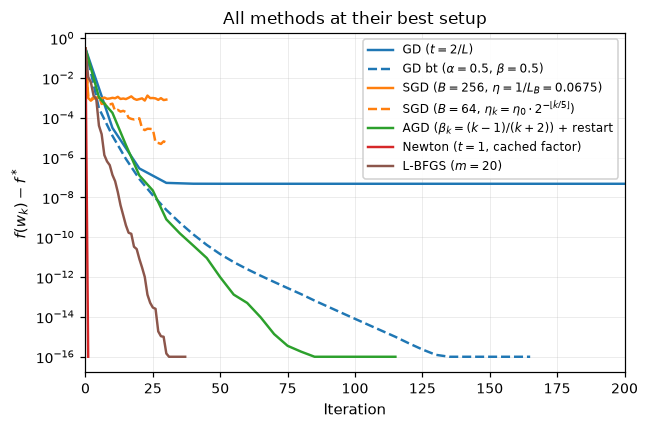

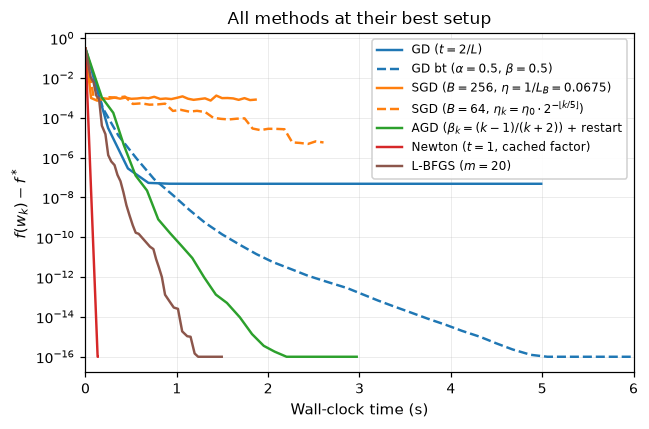

In [4]:
plot_comparison(
    best,
    problem.f_star,
    stem="all_methods",
    title="All methods at their best setup",
    color_by="method",
    # Gradient descent runs on to iteration 1200 and 44 s. Without a clip it
    # compresses the other six curves into the left margin; the caption in the
    # report says where it ends.
    xlims={"iter": (0, 200), "time": (0, 6)},
)
plt.show()

## Bảng tổng hợp

In [5]:
table = summary_table(best, problem.f_star, threshold=THRESHOLD)
table

,method,setup,status,iters_to_1e-06,time_to_1e-06_s,final_f,final_gap,final_grad_norm,total_time_s,n_f_evals,n_grad_evals,n_sample_grads
0,gradient_descent,GD ($t = 2/L$),stalled,20.0,0.464670,0.023743,4.878272e-08,5.116410e-04,4.989693,221,221,35360000
1,gradient_descent,"GD bt ($\alpha = 0.5$, $\beta = 0.5$)",stalled,15.0,0.562683,0.023743,-3.469447e-18,7.716769e-10,7.227445,544,166,87040000
2,sgd,"SGD ($B = 256$, $\eta = 1/L_B = 0.0675$)",max_iter,NaN,NaN,0.024567,8.237336e-04,4.375371e-02,1.862782,0,0,4800000
3,sgd,"SGD ($B = 64$, $\eta_k = \eta_0 \cdot 2^{-\lfl...",max_iter,NaN,NaN,0.023749,5.796597e-06,3.812442e-03,2.606335,0,0,4800000
4,accelerated_gradient,AGD ($\beta_k = (k-1)/(k+2)$) + restart,converged,20.0,0.548427,0.023743,-3.469447e-18,3.205723e-11,2.969480,115,116,18560000
5,newton,"Newton ($t = 1$, cached factor)",converged,1.0,0.132985,0.023743,0.000000e+00,5.617266e-15,0.132999,2,2,480000
6,lbfgs,L-BFGS ($m = 20$),stalled,8.0,0.281733,0.023743,0.000000e+00,4.016495e-09,1.492005,93,38,14880000


In [6]:
from src.baselines import rmse
from src.data import load_test_set

X_test, y_test = load_test_set()
table["rmse_test"] = [rmse(problem, res.w_final, X_test, y_test) for res in best]
table.to_csv(ROOT / "results" / "raw" / "summary_all_methods.csv", index=False)
table

,method,setup,status,iters_to_1e-06,time_to_1e-06_s,final_f,final_gap,final_grad_norm,total_time_s,n_f_evals,n_grad_evals,n_sample_grads,rmse_test
0,gradient_descent,GD ($t = 2/L$),stalled,20.0,0.464670,0.023743,4.878272e-08,5.116410e-04,4.989693,221,221,35360000,0.206012
1,gradient_descent,"GD bt ($\alpha = 0.5$, $\beta = 0.5$)",stalled,15.0,0.562683,0.023743,-3.469447e-18,7.716769e-10,7.227445,544,166,87040000,0.206014
2,sgd,"SGD ($B = 256$, $\eta = 1/L_B = 0.0675$)",max_iter,NaN,NaN,0.024567,8.237336e-04,4.375371e-02,1.862782,0,0,4800000,0.209855
3,sgd,"SGD ($B = 64$, $\eta_k = \eta_0 \cdot 2^{-\lfl...",max_iter,NaN,NaN,0.023749,5.796597e-06,3.812442e-03,2.606335,0,0,4800000,0.206039
4,accelerated_gradient,AGD ($\beta_k = (k-1)/(k+2)$) + restart,converged,20.0,0.548427,0.023743,-3.469447e-18,3.205723e-11,2.969480,115,116,18560000,0.206014
5,newton,"Newton ($t = 1$, cached factor)",converged,1.0,0.132985,0.023743,0.000000e+00,5.617266e-15,0.132999,2,2,480000,0.206014
6,lbfgs,L-BFGS ($m = 20$),stalled,8.0,0.281733,0.023743,0.000000e+00,4.016495e-09,1.492005,93,38,14880000,0.206014


Kết luận cần viết ra: thuật toán nào nhanh nhất theo số vòng lặp, thuật toán nào
nhanh nhất theo thời gian, và vì sao thứ hạng thay đổi giữa hai hình.